# Aptura Tech Solutions — Data Science Internship (Batch 02)
## Week 01 Task: Exploratory Data Analysis (EDA)

**Intern:** Sana Ullah
**Dataset:** Diamonds (53,940 records, sourced from the `seaborn` built-in dataset library, originally from the `ggplot2` diamonds dataset)
**Target Variable:** `price` (USD)

This notebook performs a complete EDA workflow: data cleaning, missing value handling, feature analysis, visualization, and correlation analysis, followed by answers to the two assignment questions.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", None)

## 1. Load Dataset

In [2]:
df = pd.read_csv("diamonds.csv")
print("Shape:", df.shape)
df.head()

Shape: (53940, 10)


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53940 non-null  float64
 1   cut      53940 non-null  str    
 2   color    53940 non-null  str    
 3   clarity  53940 non-null  str    
 4   depth    53940 non-null  float64
 5   table    53940 non-null  float64
 6   price    53940 non-null  int64  
 7   x        53940 non-null  float64
 8   y        53940 non-null  float64
 9   z        53940 non-null  float64
dtypes: float64(6), int64(1), str(3)
memory usage: 4.1 MB


## 2. Data Cleaning

In [4]:
print("Duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)

Duplicate rows: 146
Shape after removing duplicates: (53794, 10)


In [5]:
# x, y, z are physical dimensions in mm - a value of 0 is physically invalid
print("Rows with zero dimension values:")
print((df[["x","y","z"]] == 0).sum())

for col in ["x", "y", "z"]:
    df.loc[df[col] == 0, col] = np.nan

Rows with zero dimension values:
x     7
y     6
z    19
dtype: int64


## 3. Missing Value Handling

In [6]:
print("Missing values before imputation:")
print(df.isnull().sum())

for col in ["x", "y", "z"]:
    df[col] = df[col].fillna(df[col].median())

print("\nMissing values after imputation:")
print(df.isnull().sum())

Missing values before imputation:
carat       0
cut         0
color       0
clarity     0
depth       0
table       0
price       0
x           7
y           6
z          19
dtype: int64

Missing values after imputation:
carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64


In [7]:
# Remove statistically implausible outliers using IQR (k=3 for extreme-only removal)
def iqr_bounds(series, k=3.0):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return q1 - k*iqr, q3 + k*iqr

low, high = iqr_bounds(df["carat"])
before = len(df)
df = df[(df["carat"] >= low) & (df["carat"] <= high)]
print(f"Outlier rows removed (carat): {before - len(df)}")
print("Final cleaned shape:", df.shape)

Outlier rows removed (carat): 38
Final cleaned shape: (53756, 10)


## 4. Feature Analysis — Descriptive Statistics

In [8]:
df.describe().round(2)

,carat,depth,table,price,x,y,z
count,53756.00,53756.00,53756.00,53756.00,53756.00,53756.00,53756.00
mean,0.80,61.75,57.46,3925.61,5.73,5.73,3.54
std,0.47,1.43,2.23,3978.54,1.11,1.14,0.70
min,0.20,43.00,43.00,326.00,3.73,3.68,1.07
25%,0.40,61.00,56.00,950.00,4.71,4.72,2.91
50%,0.70,61.80,57.00,2401.00,5.70,5.71,3.53
75%,1.04,62.50,59.00,5316.00,6.54,6.53,4.03
max,2.80,79.00,95.00,18823.00,9.17,58.90,31.80


In [9]:
for col in ["cut", "color", "clarity"]:
    print(f"\n{col} value counts:")
    print(df[col].value_counts())


cut value counts:


cut
Ideal        21484
Premium      13733
Very Good    12066
Good          4886
Fair          1587
Name: count, dtype: int64

color value counts:
color
G    11260
E     9774
F     9519
H     8264
D     6754
I     5393
J     2792
Name: count, dtype: int64

clarity value counts:
clarity
SI1     13032
VS2     12228
SI2      9137
VS1      8156
VVS2     5056
VVS1     3647
IF       1784
I1        716
Name: count, dtype: int64


## 5. Visualization

### 5.1 Target Variable Distribution

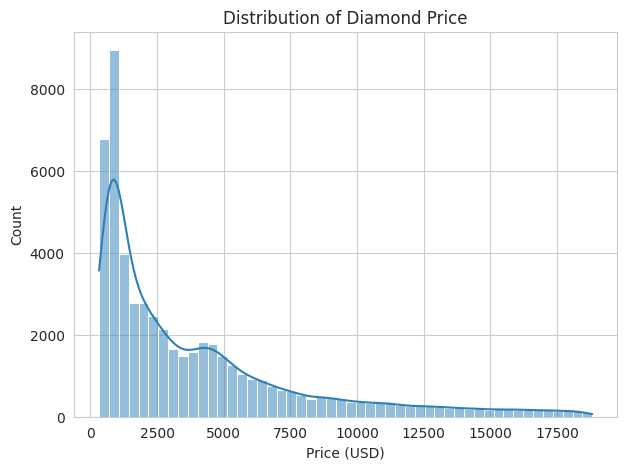

In [10]:
plt.figure(figsize=(7,5))
sns.histplot(df["price"], bins=50, kde=True, color="#2c7fb8")
plt.title("Distribution of Diamond Price")
plt.xlabel("Price (USD)")
plt.show()

### 5.2 Carat vs Price

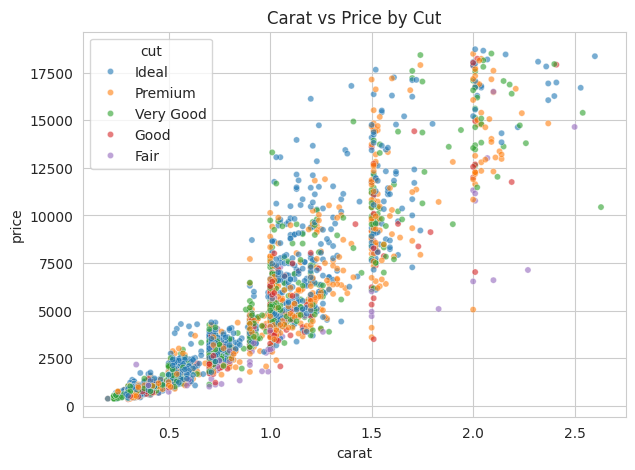

In [11]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=df.sample(3000, random_state=1), x="carat", y="price", hue="cut", alpha=0.6, s=20)
plt.title("Carat vs Price by Cut")
plt.show()

### 5.3 Price Across Categorical Features

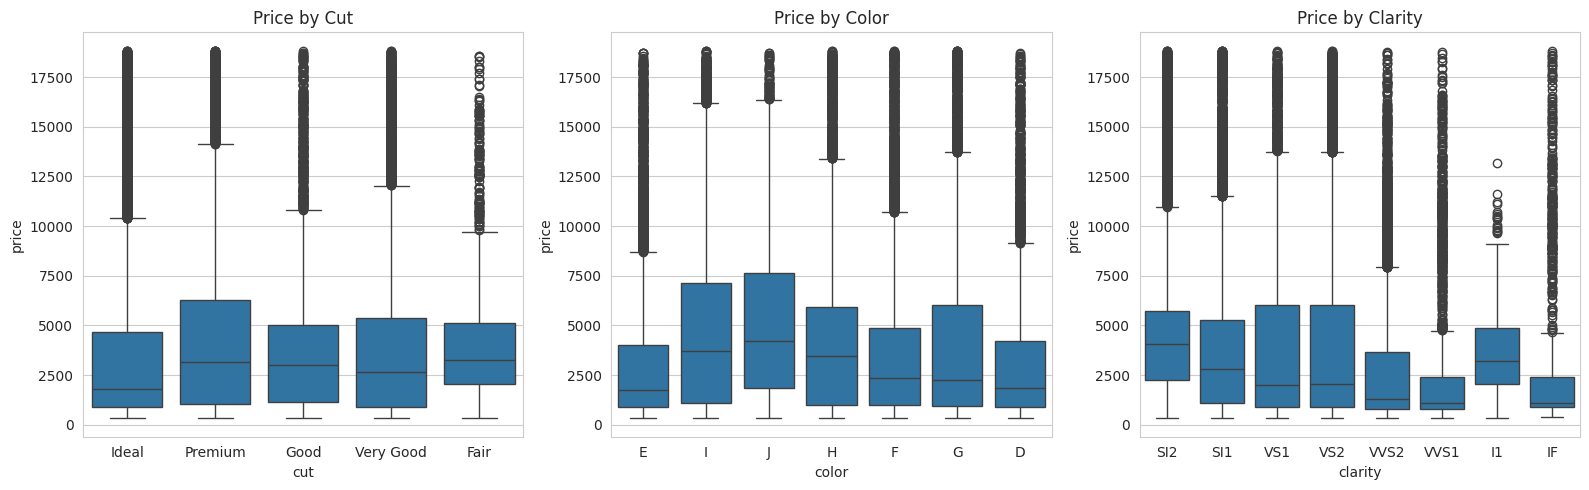

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16,5))
for ax, col in zip(axes, ["cut", "color", "clarity"]):
    sns.boxplot(data=df, x=col, y="price", ax=ax)
    ax.set_title(f"Price by {col.capitalize()}")
plt.tight_layout()
plt.show()

## 6. Correlation Analysis

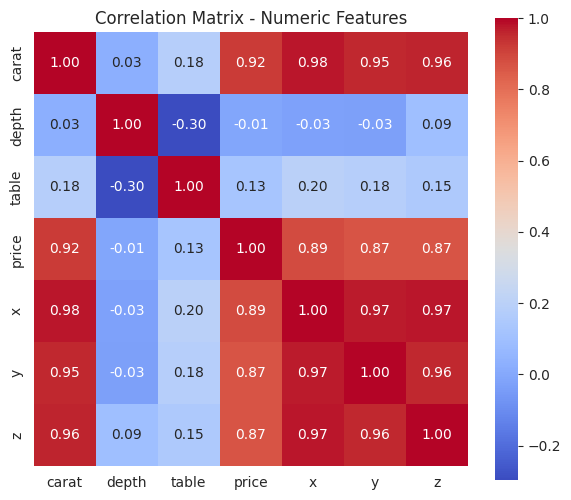

price    1.000000
carat    0.923489
x        0.886556
y        0.866969
z        0.866967
table    0.125812
depth   -0.012011
Name: price, dtype: float64

In [13]:
numeric_cols = ["carat", "depth", "table", "price", "x", "y", "z"]
corr = df[numeric_cols].corr()

plt.figure(figsize=(7,6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Matrix - Numeric Features")
plt.show()

corr["price"].sort_values(ascending=False)

## 7. Question 01 — Three Most Influential Features Affecting Price

A Random Forest Regressor is used to rank feature importance, cross-checked against the correlation matrix above.

In [14]:
model_df = df.copy()
cut_order = [["Fair","Good","Very Good","Premium","Ideal"]]
color_order = [["J","I","H","G","F","E","D"]]
clarity_order = [["I1","SI2","SI1","VS2","VS1","VVS2","VVS1","IF"]]

model_df["cut"] = OrdinalEncoder(categories=cut_order).fit_transform(model_df[["cut"]])
model_df["color"] = OrdinalEncoder(categories=color_order).fit_transform(model_df[["color"]])
model_df["clarity"] = OrdinalEncoder(categories=clarity_order).fit_transform(model_df[["clarity"]])

X = model_df.drop(columns=["price"])
y = model_df["price"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1, max_depth=12)
rf.fit(X_train, y_train)

importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print("R2 on test set:", round(rf.score(X_test, y_test), 4))
importances

R2 on test set: 0.9822


carat      0.574017
y          0.317718
clarity    0.064031
color      0.032736
x          0.004254
z          0.003507
depth      0.001462
cut        0.001211
table      0.001065
dtype: float64

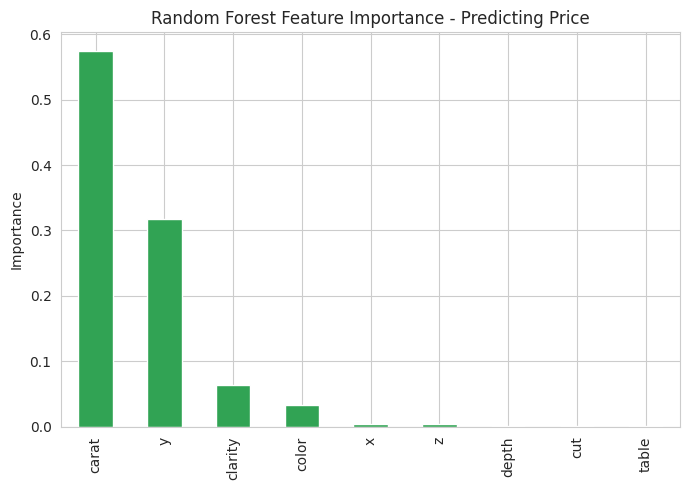

In [15]:
plt.figure(figsize=(7,5))
importances.plot(kind="bar", color="#31a354")
plt.title("Random Forest Feature Importance - Predicting Price")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

**Answer:** The three most influential features affecting `price` are:

1. **carat** — importance score ~0.57 (Random Forest) and Pearson correlation of ~0.92 with price. Carat is the physical weight of the diamond and is by far the dominant price driver, consistent with market pricing conventions.
2. **y (width dimension, mm)** — importance ~0.32 and correlation ~0.87 with price. This is expected since dimension is mathematically linked to carat/volume, so it captures overlapping size information.
3. **clarity** — importance ~0.06. After controlling for size, clarity grade is the next strongest differentiator, since it directly affects a diamond's visual quality and market grading.

The remaining features (`cut`, `color`, `depth`, `table`, `x`, `z`) contribute marginally once carat and the correlated dimension fields are accounted for, since `x` and `z` are collinear with `y` and carat.

## 8. Question 02 — Scaling from 1,000 Rows to 10 Million Rows

**Challenges that would arise:**

1. **Memory limitations** — a 10 million row dataset cannot be fully loaded into RAM using standard pandas on a typical machine, leading to crashes or heavy swapping.
2. **Slow computation** — operations such as `.corr()`, `groupby`, and `pairplot` scale poorly and would take an impractical amount of time on the full in-memory dataset.
3. **Visualization overload** — plotting 10 million points directly produces unreadable, overplotted charts and can freeze plotting libraries.
4. **I/O bottlenecks** — reading/writing a single large CSV repeatedly becomes a major bottleneck compared to columnar or chunked formats.
5. **Data quality at scale** — missing values, duplicates, and outliers become harder to detect and handle manually; automated, scalable routines are required.

**Redesigned workflow for efficient processing:**

1. **Switch storage format** — convert the raw CSV to a columnar format such as Parquet, which is compressed and far faster to read/write than CSV.
2. **Use chunked or out-of-core processing** — read data in chunks with `pandas.read_csv(chunksize=...)`, or use libraries built for larger-than-memory data such as Dask, Polars, or Vaex, which parallelize operations across cores.
3. **Distributed processing for very large scale** — if data grows beyond a single machine's capacity, move to Spark (PySpark) for distributed cleaning, aggregation, and correlation computation across a cluster.
4. **Sampling for exploration** — perform initial EDA, visualization, and hypothesis generation on a representative random sample (e.g. 1-5%), then validate key findings against the full dataset.
5. **Efficient visualization** — use aggregated plots (hexbin, 2D histograms, downsampled scatter plots) instead of plotting every raw point.
6. **Optimize data types** — downcast numeric types (e.g. float64 to float32, int64 to int32) and convert repeated string categories to the `category` dtype to substantially reduce memory footprint.
7. **Incremental/streaming feature engineering** — compute statistics (mean, std, correlation) using online/incremental algorithms rather than recomputing over the full dataset each time.
8. **Pipeline automation** — move the workflow into a script/pipeline (rather than interactive notebook cells) with logging and checkpointing, so long-running jobs can resume after failure rather than restart from zero.

## 9. Summary

The cleaned diamonds dataset shows that diamond price is overwhelmingly driven by physical size (carat and its correlated dimension fields), with clarity providing secondary influence. The Random Forest model achieved an R2 of ~0.98 on the held-out test set, confirming that these features explain price variation very well. Scaling this workflow to 10 million rows would require a shift from in-memory pandas processing to columnar storage, sampling, and distributed or out-of-core computation frameworks.